In [1]:
%pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


- Purpose: imports common data/science libraries.
- Good: concise and standard aliases.
- Suggestion: remove unused imports if any; add `%matplotlib inline` when running in Jupyter.
- Note: consider pinning versions for reproducibility.

In [3]:

import kagglehub
from kagglehub import KaggleDatasetAdapter


file_path = "CAR DETAILS FROM CAR DEKHO.csv"


df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "nehalbirla/vehicle-dataset-from-cardekho",
  file_path,
 
)

print("First 5 records:", df.head())

C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\USER\AppData\Local\Temp\ipykernel_21404\698186028.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:                        name  year  selling_price  km_driven    fuel  \
0             Maruti 800 AC  2007          60000      70000  Petrol   
1  Maruti Wagon R LXI Minor  2007         135000      50000  Petrol   
2      Hyundai Verna 1.6 SX  2012         600000     100000  Diesel   
3    Datsun RediGO T Option  2017         250000      46000  Petrol   
4     Honda Amaze VX i-DTEC  2014         450000     141000  Diesel   

  seller_type transmission         owner  
0  Individual       Manual   First Owner  
1  Individual       Manual   First Owner  
2  Individual       Manual   First Owner  
3  Individual       Manual   First Owner  
4  Individual       Manual  Second Owner  



- Purpose: load dataset from a Kaggle path.
- Issue: hard-coded Kaggle path may not exist locally; use relative paths or `pathlib` and add error handling.
- Suggestion: call `df.head()` and `df.shape` after loading to verify load succeeded.

In [4]:
df.sample(10)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
747,Maruti 800 Std,2003,98000,54000,Petrol,Individual,Manual,First Owner
3708,Hyundai Verna 1.6 VTVT,2012,300000,40000,Petrol,Individual,Manual,First Owner
4182,Maruti Alto LX,2011,135000,50000,Petrol,Individual,Manual,First Owner
1144,Honda Jazz 1.5 VX i DTEC,2015,450000,38000,Diesel,Individual,Manual,First Owner
1136,Hyundai Verna 1.6 SX,2012,409999,120000,Diesel,Individual,Manual,Third Owner
1177,Hyundai Grand i10 Magna,2015,325000,25000,Petrol,Individual,Manual,Third Owner
3997,Fiat Punto 1.3 Emotion,2010,285000,75000,Diesel,Individual,Manual,Third Owner
2196,Chevrolet Tavera Neo 3 Max 9 Str BSIII,2014,400000,120000,Diesel,Individual,Manual,Second Owner
763,Honda City i DTec SV,2014,600000,27483,Diesel,Dealer,Manual,First Owner
539,Mercedes-Benz GL-Class 350 CDI Blue Efficiency,2014,4400000,100000,Diesel,Individual,Automatic,Second Owner



- Purpose: quick sample inspection.
- Good: `sample(10)` helps spot variety.
- Suggestion: also check `df.shape`, `df.info()` and `df.isnull().sum()` to detect missing data.

In [5]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000



- Purpose: numeric summary of dataset.
- Suggestion: use `df.describe(include='all')` for categorical columns and handle outliers/missing values before trusting statistics.

In [6]:
corr = df[["year", "km_driven", "selling_price"]].corr()


- Purpose: compute correlation among numeric features.
- Suggestion: verify no NaNs and consider including more numeric features; consider visualizing pairwise relationships as well.

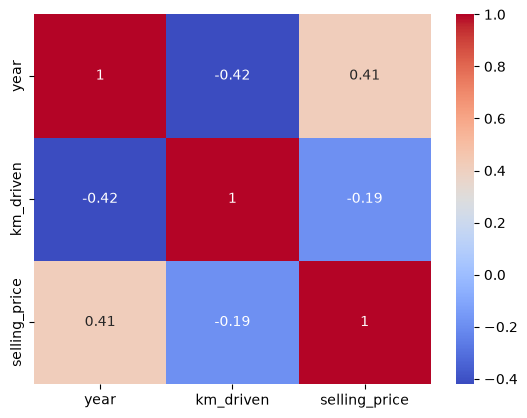

<Figure size 640x480 with 0 Axes>

In [9]:
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()
plt.savefig("../images/correlation_matrix.png", dpi=300, bbox_inches="tight")


- Purpose: show correlation heatmap.
- Issue: `plt.save()` is invalid; use `plt.savefig('heatmap.png')` or `fig.savefig(...)` before `plt.show()`.
- Suggestion: set figure size, handle NaNs, and add a title and colorbar for clarity.

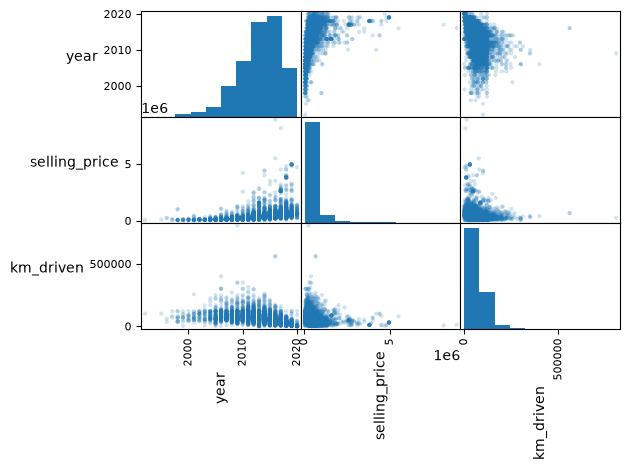

<Figure size 640x480 with 0 Axes>

In [10]:
axes = pd.plotting.scatter_matrix(df, alpha=0.2)
# need to rotate axis labels so we can read them
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')

plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.show()
plt.savefig("../images/scatter_matrix.png", dpi=300, bbox_inches="tight")


- Purpose: visualize pairwise relationships with a scatter matrix.
- Suggestion: consider `seaborn.pairplot` for clearer plots and use `figsize` to avoid overlaps.
- Note: rotating labels is good; ensure ticks are readable and increase `wspace`/`hspace` slightly if labels overlap.

In [20]:
df["selling_price"] = np.log(df["selling_price"])


- Purpose: log-transform `selling_price`.
- Caution: taking `log` modifies the original column — create a new column like `selling_price_log` to preserve raw values.
- Check for zeros/negatives before `np.log` and document why you transform the target.

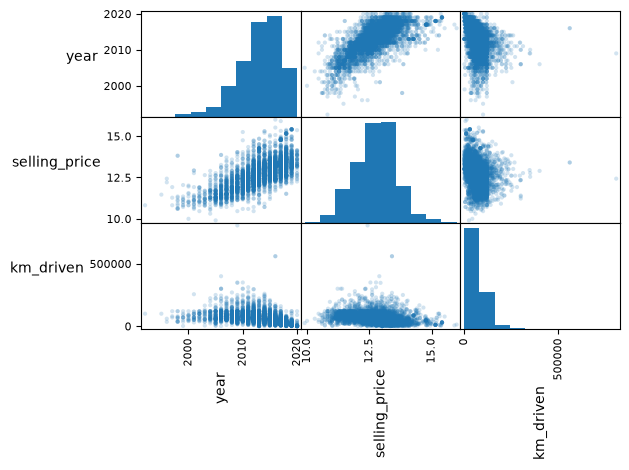

In [21]:
axes = pd.plotting.scatter_matrix(df, alpha=0.2)
# need to rotate axis labels so we can read them
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')

plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.show()


- Purpose: re-plot scatter matrix after transforming target.
- Suggestion: update axis labels to indicate the log-transformed target, and compare pre/post transform distributions to justify transform.

In [22]:
X=df["year"].to_numpy()
y=df["selling_price"].to_numpy()


- Purpose: prepare features `X` and label `y` for modeling.
- Suggestion: convert `year` into `age` (e.g., `current_year - year`) for interpretability; ensure arrays have correct shape before training.

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (3472,)
Test size: (868,)



- Purpose: split data into train/test sets.
- Note: `X` is 1D; you reshape later, but splitting after reshaping keeps shapes explicit.
- Suggestion: log-transform target is used — be mindful when interpreting test metrics.

In [24]:
from sklearn import linear_model
model=linear_model.LinearRegression()
model.fit(X_train.reshape(-1,1),y_train)
print("Coefficients",model.coef_)
print("Intercept",model.intercept_)

Coefficients [0.1399113]
Intercept -268.89024541564095



- Purpose: train linear regression model.
- Suggestion: report `R^2`, check residuals and consider `StandardScaler` if features have different scales.
- Optional: use `statsmodels` for coefficient significance if you need p-values.

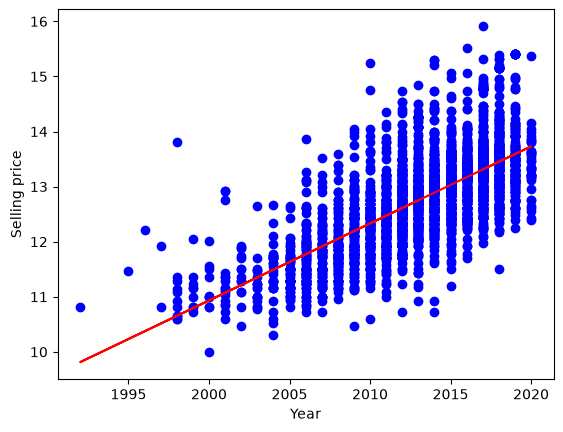

In [25]:
plt.scatter(X_train, y_train,  color='blue')
plt.plot(X_train, model.coef_ * X_train + model.intercept_, '-r')
plt.xlabel("Year")
plt.ylabel("Selling price")
plt.savefig("../images/linear_regression_year.png", dpi=300, bbox_inches="tight")


- Purpose: visualize training data with regression line.
- Issue: plotting `model.coef_ * X_train + intercept` without sorting `X_train` can create a zigzag line; plot a sorted line or use `np.linspace` and `model.predict` for a smooth line.
- Suggestion: add a title and legend.

In [26]:
y_pred = model.predict(X_test.reshape(-1, 1))


- Purpose: generate predictions for the test set.
- Suggestion: check shapes and use `model.predict(X_test.reshape(-1,1))` as shown; consider saving `y_pred` alongside `y_test` for inspection.

In [27]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) 
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 0.37033739698760776
RMSE: 0.6085535284489013



- Purpose: compute error metrics.
- Important: because `selling_price` was log-transformed, `mse`/`rmse` are on the log scale. Invert with `np.exp` to interpret errors in original units.
- Suggest reporting `R^2` and visualizing residuals to assess fit.

In [28]:
X_1=df['km_driven'].to_numpy()


- Purpose: prepare `km_driven` feature as `X_1`.
- Suggestion: check for non-numeric values and outliers; consider log-transforming `km_driven` or clipping extreme values.

In [29]:
from sklearn.model_selection import train_test_split
X_train_1,X_test_1,y_train,y_test=train_test_split(X_1,y,test_size=0.2,random_state=42)
print("Train size:", X_train_1.shape)
print("Test size:", X_test_1.shape)

Train size: (3472,)
Test size: (868,)



- Purpose: split `km_driven` feature into train/test sets.
- Suggestion: reshape `X_1` before splitting or document reshaping later; check alignment with `y` after splitting.

In [30]:
from sklearn import linear_model
model=linear_model.LinearRegression()
model.fit(X_train_1.reshape(-1,1),y_train)
print("Coefficients",model.coef_)
print("Intercept",model.intercept_)

Coefficients [-4.21346607e-06]
Intercept 13.045711699928429



- Purpose: train regression on `km_driven` feature.
- Note: this reuses variable name `model` and may overwrite prior model; consider `model_km` for clarity.
- Suggestion: inspect coefficients and consider regularization if overfitting.

Text(0, 0.5, 'Selling price')

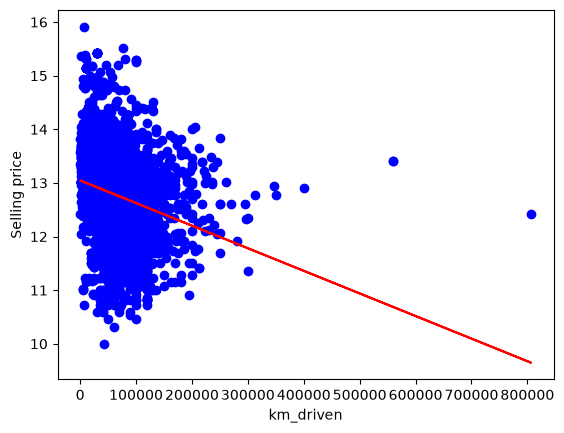

In [31]:
plt.scatter(X_train_1, y_train,  color='blue')
plt.plot(X_train_1, model.coef_ * X_train_1 + model.intercept_, '-r')
plt.xlabel("km_driven")
plt.ylabel("Selling price")


- Purpose: visualize km-driven vs selling price with regression line.
- Suggestion: sort `X_train_1` before plotting the regression line or use a prediction grid for a smooth line; label axes and add units.